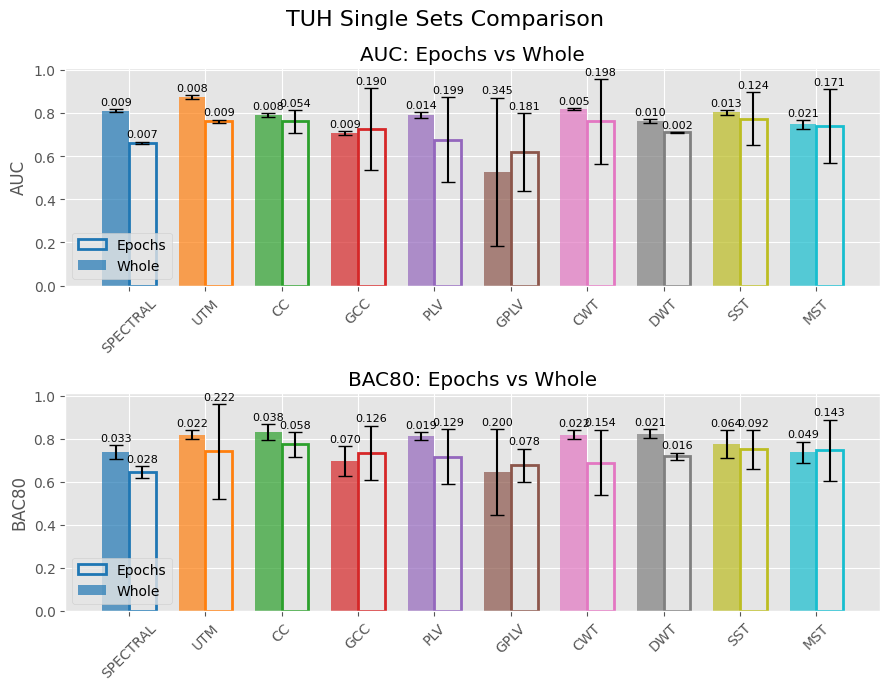

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#use ggplot style
plt.style.use('ggplot')


colors = plt.cm.tab10.colors  # or use 'Set3', 'Accent', etc., for more variety
# If there are more than 10 bars, repeat colors or use a larger colormap
colors = list(colors) * (10 // len(colors) + 1)
# TUH DATA SINGLE SET EPOCHED VERSION
data_epochs = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.66097, "AUC_STD": 0.0065279, "BAC80": 0.6453, "BAC80_STD": 0.027778},
    {"FEATURE_SET": "UTM", "AUC": 0.76068, "AUC_STD": 0.008547, "BAC80": 0.74145, "BAC80_STD": 0.22206},
    {"FEATURE_SET": "CC", "AUC": 0.76068, "AUC_STD": 0.053547, "BAC80": 0.77493, "BAC80_STD": 0.057824},
    {"FEATURE_SET": "GCC", "AUC": 0.72507, "AUC_STD": 0.19017, "BAC80": 0.73575, "BAC80_STD": 0.12555},
    {"FEATURE_SET": "PLV", "AUC": 0.67664, "AUC_STD": 0.19854, "BAC80": 0.71724, "BAC80_STD": 0.12858},
    {"FEATURE_SET": "GPLV", "AUC": 0.61823, "AUC_STD": 0.18057, "BAC80": 0.67664, "BAC80_STD": 0.078052},
    {"FEATURE_SET": "CWT", "AUC": 0.76068, "AUC_STD": 0.19845, "BAC80": 0.68946, "BAC80_STD": 0.15363},
    {"FEATURE_SET": "DWT", "AUC": 0.71083, "AUC_STD": 0.0024673, "BAC80": 0.71937, "BAC80_STD": 0.016038},
    {"FEATURE_SET": "SST", "AUC": 0.7735, "AUC_STD": 0.12364, "BAC80": 0.75071, "BAC80_STD": 0.09169},
    {"FEATURE_SET": "MST", "AUC": 0.73932, "AUC_STD": 0.17142, "BAC80": 0.74715, "BAC80_STD": 0.14254},
]

data_whole = [
    {"FEATURE_SET": "SPECTRAL", "AUC": 0.811016144, "AUC_STD": 0.0087038, "BAC80": 0.738841406, "BAC80_STD": 0.032897},
    {"FEATURE_SET": "UTM", "AUC": 0.87464, "AUC_STD": 0.0075378, "BAC80": 0.81909, "BAC80_STD": 0.022206},
    {"FEATURE_SET": "CC", "AUC": 0.79107, "AUC_STD": 0.0082244, "BAC80": 0.83191, "BAC80_STD": 0.03846},
    {"FEATURE_SET": "GCC", "AUC": 0.7056, "AUC_STD": 0.0087038, "BAC80": 0.69468, "BAC80_STD": 0.07011},
    {"FEATURE_SET": "PLV", "AUC": 0.79107, "AUC_STD": 0.01434, "BAC80": 0.81292, "BAC80_STD": 0.019235},
    {"FEATURE_SET": "GPLV", "AUC": 0.52707, "AUC_STD": 0.34473, "BAC80": 0.64625, "BAC80_STD": 0.19992},
    {"FEATURE_SET": "CWT", "AUC": 0.81766, "AUC_STD": 0.0049346, "BAC80": 0.81861, "BAC80_STD": 0.021806},
    {"FEATURE_SET": "DWT", "AUC": 0.76353, "AUC_STD": 0.0098692, "BAC80": 0.82431, "BAC80_STD": 0.021383},
    {"FEATURE_SET": "SST", "AUC": 0.80247, "AUC_STD": 0.012847, "BAC80": 0.77493, "BAC80_STD": 0.06415},
    {"FEATURE_SET": "MST", "AUC": 0.74739, "AUC_STD": 0.021, "BAC80": 0.73789, "BAC80_STD": 0.048995},
]

df_epochs = pd.DataFrame(data_epochs)
df_whole = pd.DataFrame(data_whole)

# Set up grouped bar plot parameters
x = np.arange(len(df_epochs))
width = 0.35

# Plotting AUC comparison
plt.figure(figsize=(9, 7))
plt.subplot(211)
plt.suptitle('TUH Single Sets Comparison', fontsize=16)

bars1 = plt.bar(x + width/2, df_epochs["AUC"], width, yerr=df_epochs["AUC_STD"], 
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole["AUC"], width, yerr=df_whole["AUC_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=0.7, label='Whole')

plt.ylabel("AUC")
plt.title("AUC: Epochs vs Whole")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole["AUC_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", #±
             ha='center', va='bottom', fontsize=8)

# Plotting BAC80 comparison
plt.subplot(212)
bars1 = plt.bar(x + width/2, df_epochs["BAC80"], width, yerr=df_epochs["BAC80_STD"], 
                capsize=5, color=colors[:len(df_epochs)], alpha=1, fill=False, 
                edgecolor=colors[:len(df_epochs)], linewidth=2, label='Epochs')
bars2 = plt.bar(x - width/2, df_whole["BAC80"], width, yerr=df_whole["BAC80_STD"], 
                capsize=5, color=colors[:len(df_whole)], alpha=0.7, label='Whole')

plt.ylabel("BAC80")
plt.title("BAC80: Epochs vs Whole")
plt.xticks(x, df_epochs["FEATURE_SET"], rotation=45)
plt.legend()

# Annotate std values above bars for epochs
for bar, std in zip(bars1, df_epochs["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

# Annotate std values above bars for whole
for bar, std in zip(bars2, df_whole["BAC80_STD"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + std + 0.01, f"{std:.3f}", 
             ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()